In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import time

H:\ai-ml\exercise\ai-ml-exercises\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### What is Transfer Learning?

Transfer learning is like **standing on the shoulders of giants**. Instead of training a model from scratch (which requires millions of images and days of training), you take a model that someone else already trained on a huge dataset and **fine-tune** it for your specific problem.


#### Training from Scratch vs. Transfer Learning

| Training from Scratch | Transfer Learning |
|---|---|
| 🔴 Start from random weights | 🟢 Start from pre-trained weights |
| 🔴 Need 1M+ images | 🟢 Need only 100–1000 images |
| 🔴 Days of training | 🟢 Minutes to hours |
| 🔴 May not converge | 🟢 Usually converges quickly |


#### Why It Works

A CNN trained on **ImageNet** (1.4M images, 1000 classes) learns:

- **Early layers:** Edges, colors, textures *(universal features)*
- **Middle layers:** Shapes, patterns *(somewhat universal)*
- **Later layers:** Specific objects *(task-specific)*

> **Transfer learning idea:** Keep the universal features, only retrain the task-specific parts!

In [3]:
import numpy as np
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset
from datasets import load_dataset

print("\n" + "="*60)
print("LOADING CIFAR-10 DATA")
print("="*60)

# ✅ Same transform pipeline
# Data augmentation for training (helps prevent overfitting)
train_transform = transforms.Compose([
    transforms.Resize(224),           # ResNet expects 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),  # ImageNet mean
                         (0.229, 0.224, 0.225))   # ImageNet std
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225))
])

# ✅ Load CIFAR-10 from Hugging Face instead of torchvision
hf_train = load_dataset("uoft-cs/cifar10", split="train")
hf_test = load_dataset("uoft-cs/cifar10", split="test")


# ✅ Custom Dataset wrapper to make HF data behave like torchvision
class CIFAR10FromHF(Dataset):
    """Wrap a Hugging Face CIFAR-10 split into a PyTorch Dataset."""

    def __init__(self, hf_split, transform=None):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]  # PIL Image
        label = item["label"]  # int

        if self.transform is not None:
            img = self.transform(img)

        return img, label


train_dataset = CIFAR10FromHF(hf_train, transform=train_transform)
test_dataset = CIFAR10FromHF(hf_test, transform=test_transform)


# ============================================
# ✅ Balanced subset: 500 per class → 5,000 train, 100 per class → 1,000 test
# ============================================
np.random.seed(42)

def stratified_indices(hf_split, per_class):
    """Return balanced indices across all 10 classes."""
    labels = np.array(hf_split["label"])
    indices = []
    for class_id in range(10):
        class_idx = np.where(labels == class_id)[0]
        chosen = np.random.choice(class_idx, per_class, replace=False)
        indices.extend(chosen)
    return indices

train_indices = stratified_indices(hf_train, per_class=500)  # 5,000
test_indices = stratified_indices(hf_test, per_class=100)    # 1,000

train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# ✅ Same data loaders
batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

# ✅ Same class names
classes = ['plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# ✅ Verify — now using the subset
print(f"Train images: {len(train_subset)}")
print(f"Test images:  {len(test_subset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

images, labels = next(iter(train_loader))
print(f"\nBatch shape:  {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label range:  {labels.min().item()} to {labels.max().item()}")

# ✅ Verify balance
from collections import Counter
train_labels = [hf_train[i]["label"] for i in train_indices]
print(f"\nTraining class distribution: {dict(sorted(Counter(train_labels).items()))}")


LOADING CIFAR-10 DATA
Train images: 5000
Test images:  1000
Train batches: 79
Test batches:  16

Batch shape:  torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Label range:  0 to 9

Training class distribution: {0: 500, 1: 500, 2: 500, 3: 500, 4: 500, 5: 500, 6: 500, 7: 500, 8: 500, 9: 500}


In [4]:
print("\n" + "="*60)
print("APPROACH 1 - TRAINING FROM SCRATCH (Baseline)")
print("="*60)

class SimpleCNN(nn.Module):
    """A simple CNN to train from scratch"""
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 224 → 112
        x = self.pool(self.relu(self.conv2(x)))  # 112 → 56
        x = self.pool(self.relu(self.conv3(x)))  # 56 → 28
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

def train_and_evaluate(model, model_name, epochs=10):
    """Train and evaluate a model"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_accs = []
    test_accs = []
    losses = []
    
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training
        model.train()
        correct_train = 0
        total_train = 0
        running_loss = 0.0
        
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        train_acc = 100 * correct_train / total_train
        train_accs.append(train_acc)
        losses.append(running_loss / len(train_loader))
        
        # Testing
        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        test_acc = 100 * correct_test / total_test
        test_accs.append(test_acc)
        
        if epoch % 2 == 0:
            print(f"  {model_name} Epoch {epoch+1}/{epochs} - Train: {train_acc:.2f}%, Test: {test_acc:.2f}%")
    
    train_time = time.time() - start_time
    
    return train_accs, test_accs, losses, train_time

print("Training from scratch (this will be slow and inaccurate with only 5000 samples)...")
scratch_model = SimpleCNN()
scratch_train, scratch_test, scratch_loss, scratch_time = train_and_evaluate(
    scratch_model, "Scratch", epochs=10
)

print(f"\nFrom Scratch - Final Test Accuracy: {scratch_test[-1]:.2f}%")
print(f"From Scratch - Training Time: {scratch_time:.1f}s")




APPROACH 1 - TRAINING FROM SCRATCH (Baseline)
Training from scratch (this will be slow and inaccurate with only 5000 samples)...
  Scratch Epoch 1/10 - Train: 17.78%, Test: 30.50%
  Scratch Epoch 3/10 - Train: 35.12%, Test: 38.20%
  Scratch Epoch 5/10 - Train: 39.56%, Test: 44.30%
  Scratch Epoch 7/10 - Train: 42.86%, Test: 45.30%
  Scratch Epoch 9/10 - Train: 45.84%, Test: 47.50%

From Scratch - Final Test Accuracy: 46.70%
From Scratch - Training Time: 2559.6s


In [5]:
print("\n" + "="*60)
print("APPROACH 2 - FEATURE EXTRACTION")
print("="*60)

print("""
Feature Extraction Strategy:
• Load pre-trained ResNet-18 (trained on ImageNet)
• Freeze ALL convolutional layers (don't update them)
• Replace final layer with new classifier for CIFAR-10
• Only train the new classifier
""")

def create_feature_extractor():
    """Create a feature extractor using pre-trained ResNet"""
    # Load pre-trained ResNet-18
    model = models.resnet18(pretrained=True)
    
    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    
    # Replace final layer (only this layer will be trained)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 10)
    
    return model

feature_model = create_feature_extractor()
print("\nFeature Extractor Architecture:")
print("  • Pre-trained ResNet-18 (ImageNet weights)")
print("  • All conv layers FROZEN")
print("  • New final layer: 512 → 10")
print(f"  • Trainable parameters: {sum(p.numel() for p in feature_model.parameters() if p.requires_grad):,}")

print("\nTraining Feature Extractor...")
feature_train, feature_test, feature_loss, feature_time = train_and_evaluate(
    feature_model, "Feature Extractor", epochs=10
)

print(f"\nFeature Extraction - Final Test Accuracy: {feature_test[-1]:.2f}%")
print(f"Feature Extraction - Training Time: {feature_time:.1f}s")



APPROACH 2 - FEATURE EXTRACTION

Feature Extraction Strategy:
• Load pre-trained ResNet-18 (trained on ImageNet)
• Freeze ALL convolutional layers (don't update them)
• Replace final layer with new classifier for CIFAR-10
• Only train the new classifier



H:\ai-ml\exercise\ai-ml-exercises\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
H:\ai-ml\exercise\ai-ml-exercises\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\rah/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 10.2MB/s]



Feature Extractor Architecture:
  • Pre-trained ResNet-18 (ImageNet weights)
  • All conv layers FROZEN
  • New final layer: 512 → 10
  • Trainable parameters: 5,130

Training Feature Extractor...
  Feature Extractor Epoch 1/10 - Train: 43.20%, Test: 65.00%
  Feature Extractor Epoch 3/10 - Train: 70.30%, Test: 73.80%
  Feature Extractor Epoch 5/10 - Train: 73.30%, Test: 75.30%
  Feature Extractor Epoch 7/10 - Train: 74.98%, Test: 78.70%
  Feature Extractor Epoch 9/10 - Train: 74.94%, Test: 77.80%

Feature Extraction - Final Test Accuracy: 78.40%
Feature Extraction - Training Time: 1987.9s


In [6]:
print("\n" + "="*60)
print("APPROACH 3 - FINE-TUNING")
print("="*60)

print("""
Fine-Tuning Strategy:
• Load pre-trained ResNet-18
• Unfreeze LAST FEW layers (not all)
• Train with a smaller learning rate
• Allows model to adapt to new task
""")

def create_fine_tuned_model():
    """Create a fine-tuned model"""
    model = models.resnet18(pretrained=True)
    
    # Freeze early layers (keep universal features)
    # Unfreeze later layers (task-specific features)
    for name, param in model.named_parameters():
        if 'layer4' in name or 'fc' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    
    # Replace final layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 10)
    
    return model

fine_model = create_fine_tuned_model()

# Count trainable parameters
trainable = sum(p.numel() for p in fine_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in fine_model.parameters())
print(f"\nFine-Tuning Architecture:")
print(f"  • Pre-trained ResNet-18")
print(f"  • Unfrozen layers: layer4 + fc")
print(f"  • Trainable parameters: {trainable:,} / {total:,}")

print("\nTraining Fine-Tuned Model...")
fine_train, fine_test, fine_loss, fine_time = train_and_evaluate(
    fine_model, "Fine-Tuned", epochs=10
)

print(f"\nFine-Tuning - Final Test Accuracy: {fine_test[-1]:.2f}%")
print(f"Fine-Tuning - Training Time: {fine_time:.1f}s")



APPROACH 3 - FINE-TUNING

Fine-Tuning Strategy:
• Load pre-trained ResNet-18
• Unfreeze LAST FEW layers (not all)
• Train with a smaller learning rate
• Allows model to adapt to new task


Fine-Tuning Architecture:
  • Pre-trained ResNet-18
  • Unfrozen layers: layer4 + fc
  • Trainable parameters: 8,398,858 / 11,181,642

Training Fine-Tuned Model...
  Fine-Tuned Epoch 1/10 - Train: 73.36%, Test: 76.00%
  Fine-Tuned Epoch 3/10 - Train: 88.30%, Test: 84.50%
  Fine-Tuned Epoch 5/10 - Train: 92.84%, Test: 85.40%
  Fine-Tuned Epoch 7/10 - Train: 95.08%, Test: 87.00%
  Fine-Tuned Epoch 9/10 - Train: 95.62%, Test: 86.60%

Fine-Tuning - Final Test Accuracy: 86.30%
Fine-Tuning - Training Time: 2597.7s



COMPARING ALL APPROACHES


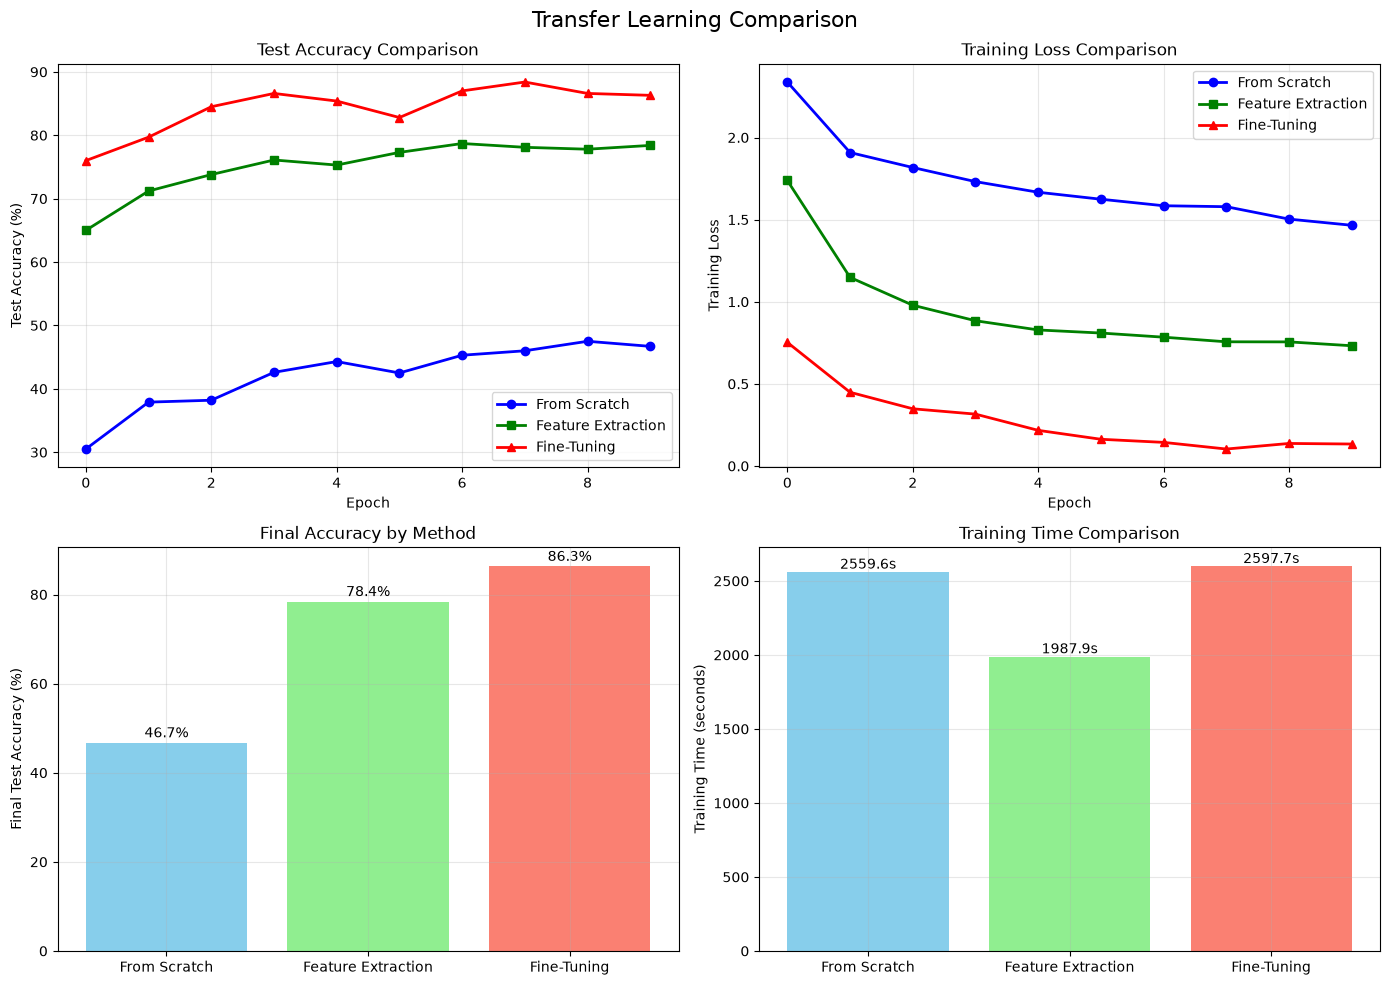

In [7]:
print("\n" + "="*60)
print("COMPARING ALL APPROACHES")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Test Accuracy
ax = axes[0, 0]
ax.plot(scratch_test, 'b-', linewidth=2, marker='o', label='From Scratch')
ax.plot(feature_test, 'g-', linewidth=2, marker='s', label='Feature Extraction')
ax.plot(fine_test, 'r-', linewidth=2, marker='^', label='Fine-Tuning')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Training Loss
ax = axes[0, 1]
ax.plot(scratch_loss, 'b-', linewidth=2, marker='o', label='From Scratch')
ax.plot(feature_loss, 'g-', linewidth=2, marker='s', label='Feature Extraction')
ax.plot(fine_loss, 'r-', linewidth=2, marker='^', label='Fine-Tuning')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Final Accuracy Bar Chart
ax = axes[1, 0]
methods = ['From Scratch', 'Feature Extraction', 'Fine-Tuning']
accuracies = [scratch_test[-1], feature_test[-1], fine_test[-1]]
colors = ['skyblue', 'lightgreen', 'salmon']
bars = ax.bar(methods, accuracies, color=colors)
ax.set_ylabel('Final Test Accuracy (%)')
ax.set_title('Final Accuracy by Method')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom')
ax.grid(True, alpha=0.3)

# Plot 4: Training Time
ax = axes[1, 1]
times = [scratch_time, feature_time, fine_time]
bars = ax.bar(methods, times, color=colors)
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{t:.1f}s', ha='center', va='bottom')
ax.grid(True, alpha=0.3)

plt.suptitle('Transfer Learning Comparison', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
print("\n" + "="*60)
print("PART 6: EVALUATING BEST MODEL (Fine-Tuning)")
print("="*60)

# Get predictions from fine-tuned model
fine_model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = fine_model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

# Classification Report
print("\nClassification Report (Fine-Tuned Model):")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)


PART 6: EVALUATING BEST MODEL (Fine-Tuning)

Classification Report (Fine-Tuned Model):
              precision    recall  f1-score   support

       plane     0.8136    0.9600    0.8807       100
         car     0.9314    0.9500    0.9406       100
        bird     0.8953    0.7700    0.8280       100
         cat     0.7383    0.7900    0.7633       100
        deer     0.8989    0.8000    0.8466       100
         dog     0.7544    0.8600    0.8037       100
        frog     0.8942    0.9300    0.9118       100
       horse     0.8557    0.8300    0.8426       100
        ship     0.9762    0.8200    0.8913       100
       truck     0.9293    0.9200    0.9246       100

    accuracy                         0.8630      1000
   macro avg     0.8687    0.8630    0.8633      1000
weighted avg     0.8687    0.8630    0.8633      1000



NameError: name 'sns' is not defined

<Figure size 1000x800 with 0 Axes>

### Transfer Learning: Key Concepts & Best Practices

#### 1. Pre-Trained Features
- ImageNet has 1.4M images, 1000 classes
- Model learned universal features (edges, shapes, textures)
- These features are useful for **ANY** image task

#### 2. Feature Extraction
- **Freeze** conv layers (keep universal features)
- Only train new classifier
- Fast, works with small datasets

#### 3. Fine-Tuning
- **Unfreeze** some layers
- Adapt features to new task
- Best accuracy, but needs more data


#### Best Practices

#### 1. Small Dataset (< 1000 images)
- → Use **Feature Extraction**
- → Freeze all conv layers
- → Only train final classifier

#### 2. Medium Dataset (1000–10000 images)
- → Use **Fine-Tuning**
- → Unfreeze last few layers
- → Use smaller learning rate

#### 3. Large Dataset (> 10000 images)
- → Train from scratch **OR**
- → Fine-tune all layers
- → More data = better fine-tuning


#### When to Use Transfer Learning

- ✅ Limited training data
- ✅ Limited compute resources
- ✅ Similar task to pre-trained model
- ✅ Need quick results

#### When NOT to Use

- ❌ Very different domain (medical images vs natural images)
- ❌ Need custom architecture
- ❌ Have massive dataset and compute